✅ Libraries imported successfully!

📂 Please upload your bank.csv file...


Saving bank.csv to bank.csv

📦 Dataset Shape: (4521, 17)
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  
age           int64
job          object
marital      o

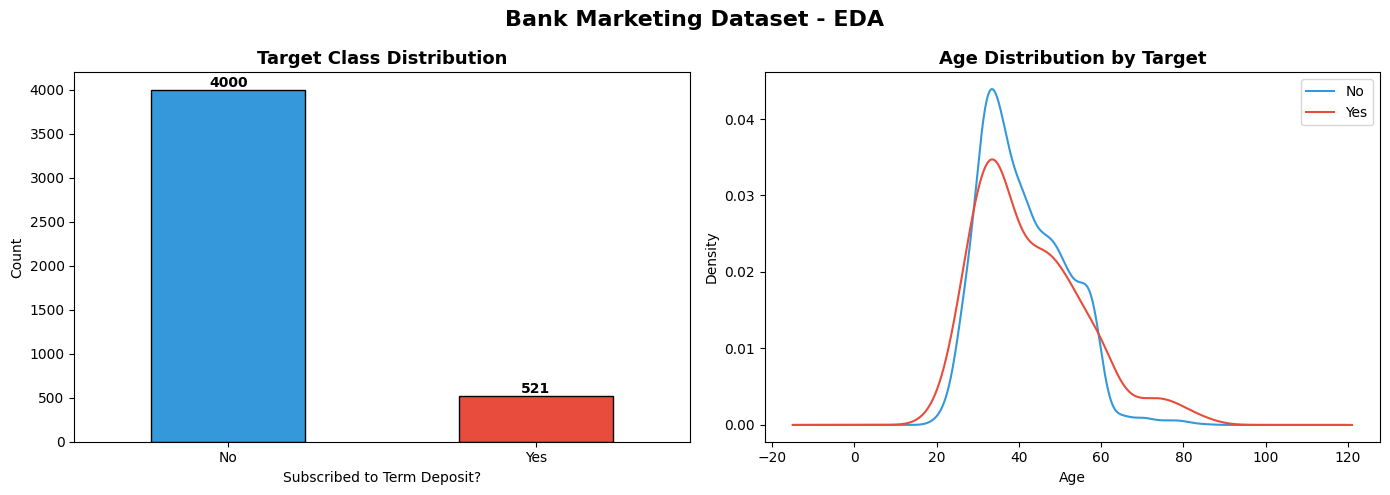

✅ EDA plot saved!


<Figure size 1400x500 with 0 Axes>

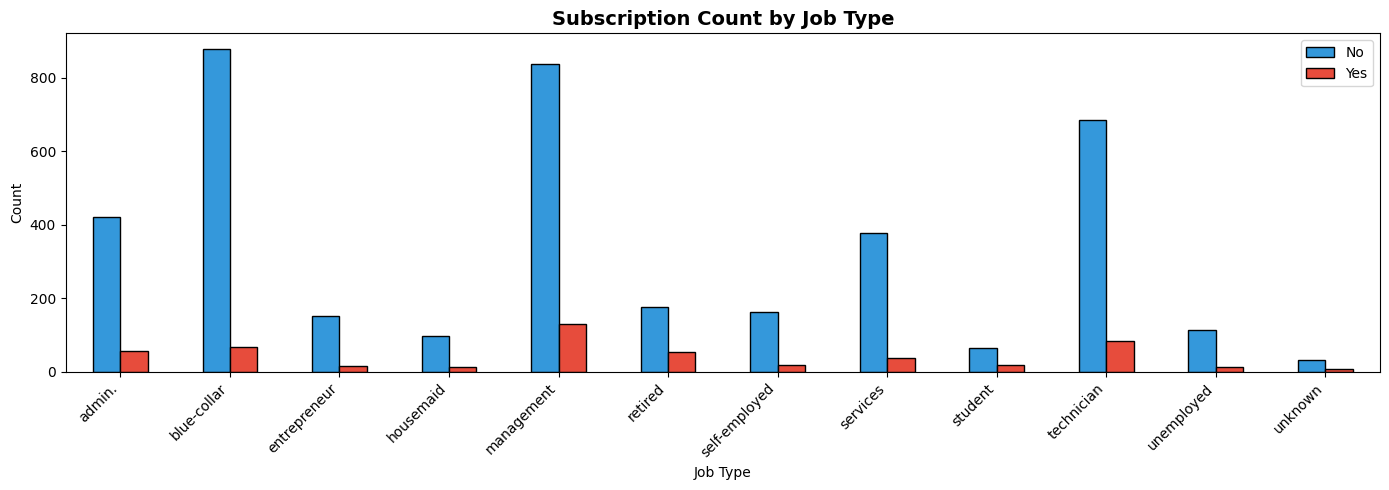

✅ EDA plot 2 saved!

🔄 Encoding 10 categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
✅ Label encoding done!

📊 Features: 16 | Samples: 4521
Feature columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

🔀 Train: 3616 samples | Test: 905 samples

✅ Decision Tree model trained!
   Tree depth: 5
   Number of leaves: 24

🎯 Model Accuracy: 88.95%

📋 Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.96      0.94       801
         Yes       0.53      0.33      0.40       104

    accuracy                           0.89       905
   macro avg       0.72      0.64      0.67       905
weighted avg       0.87      0.89      0.88       905



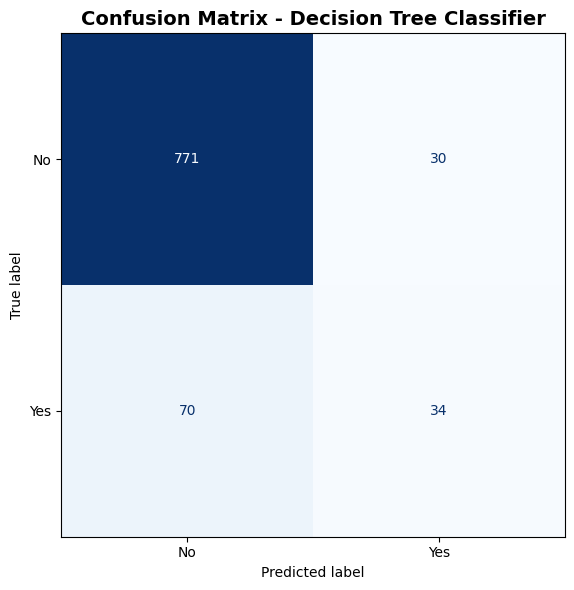

✅ Confusion matrix saved!


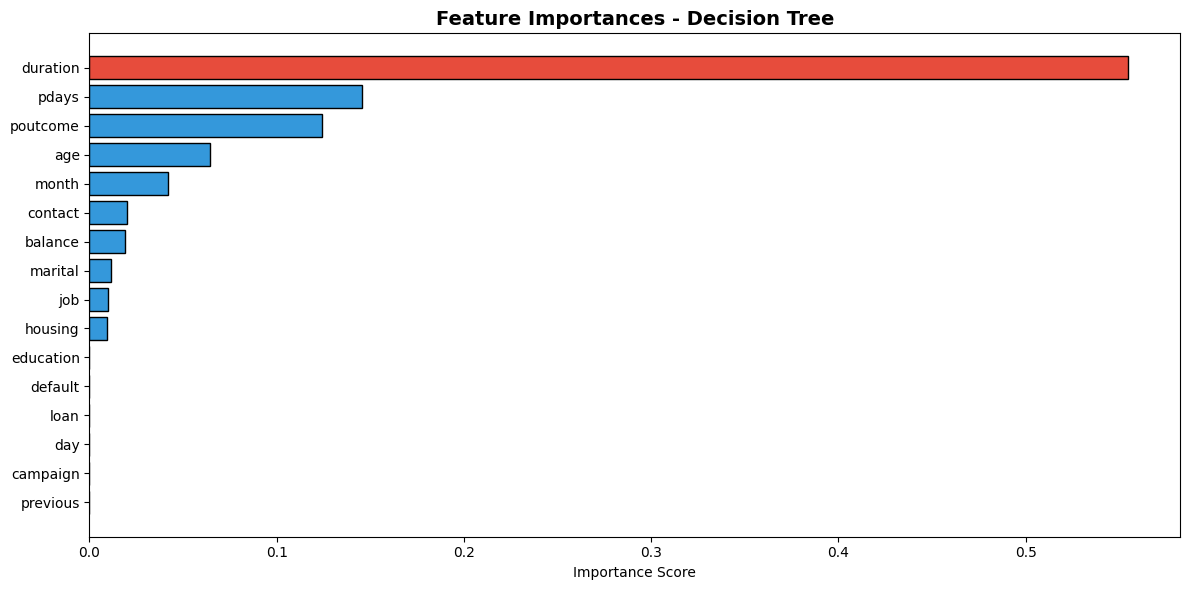


🔑 Top 5 Most Important Features:
   1. duration: 0.5547
   2. pdays: 0.1453
   3. poutcome: 0.1239
   4. age: 0.0643
   5. month: 0.0419
✅ Feature importance plot saved!


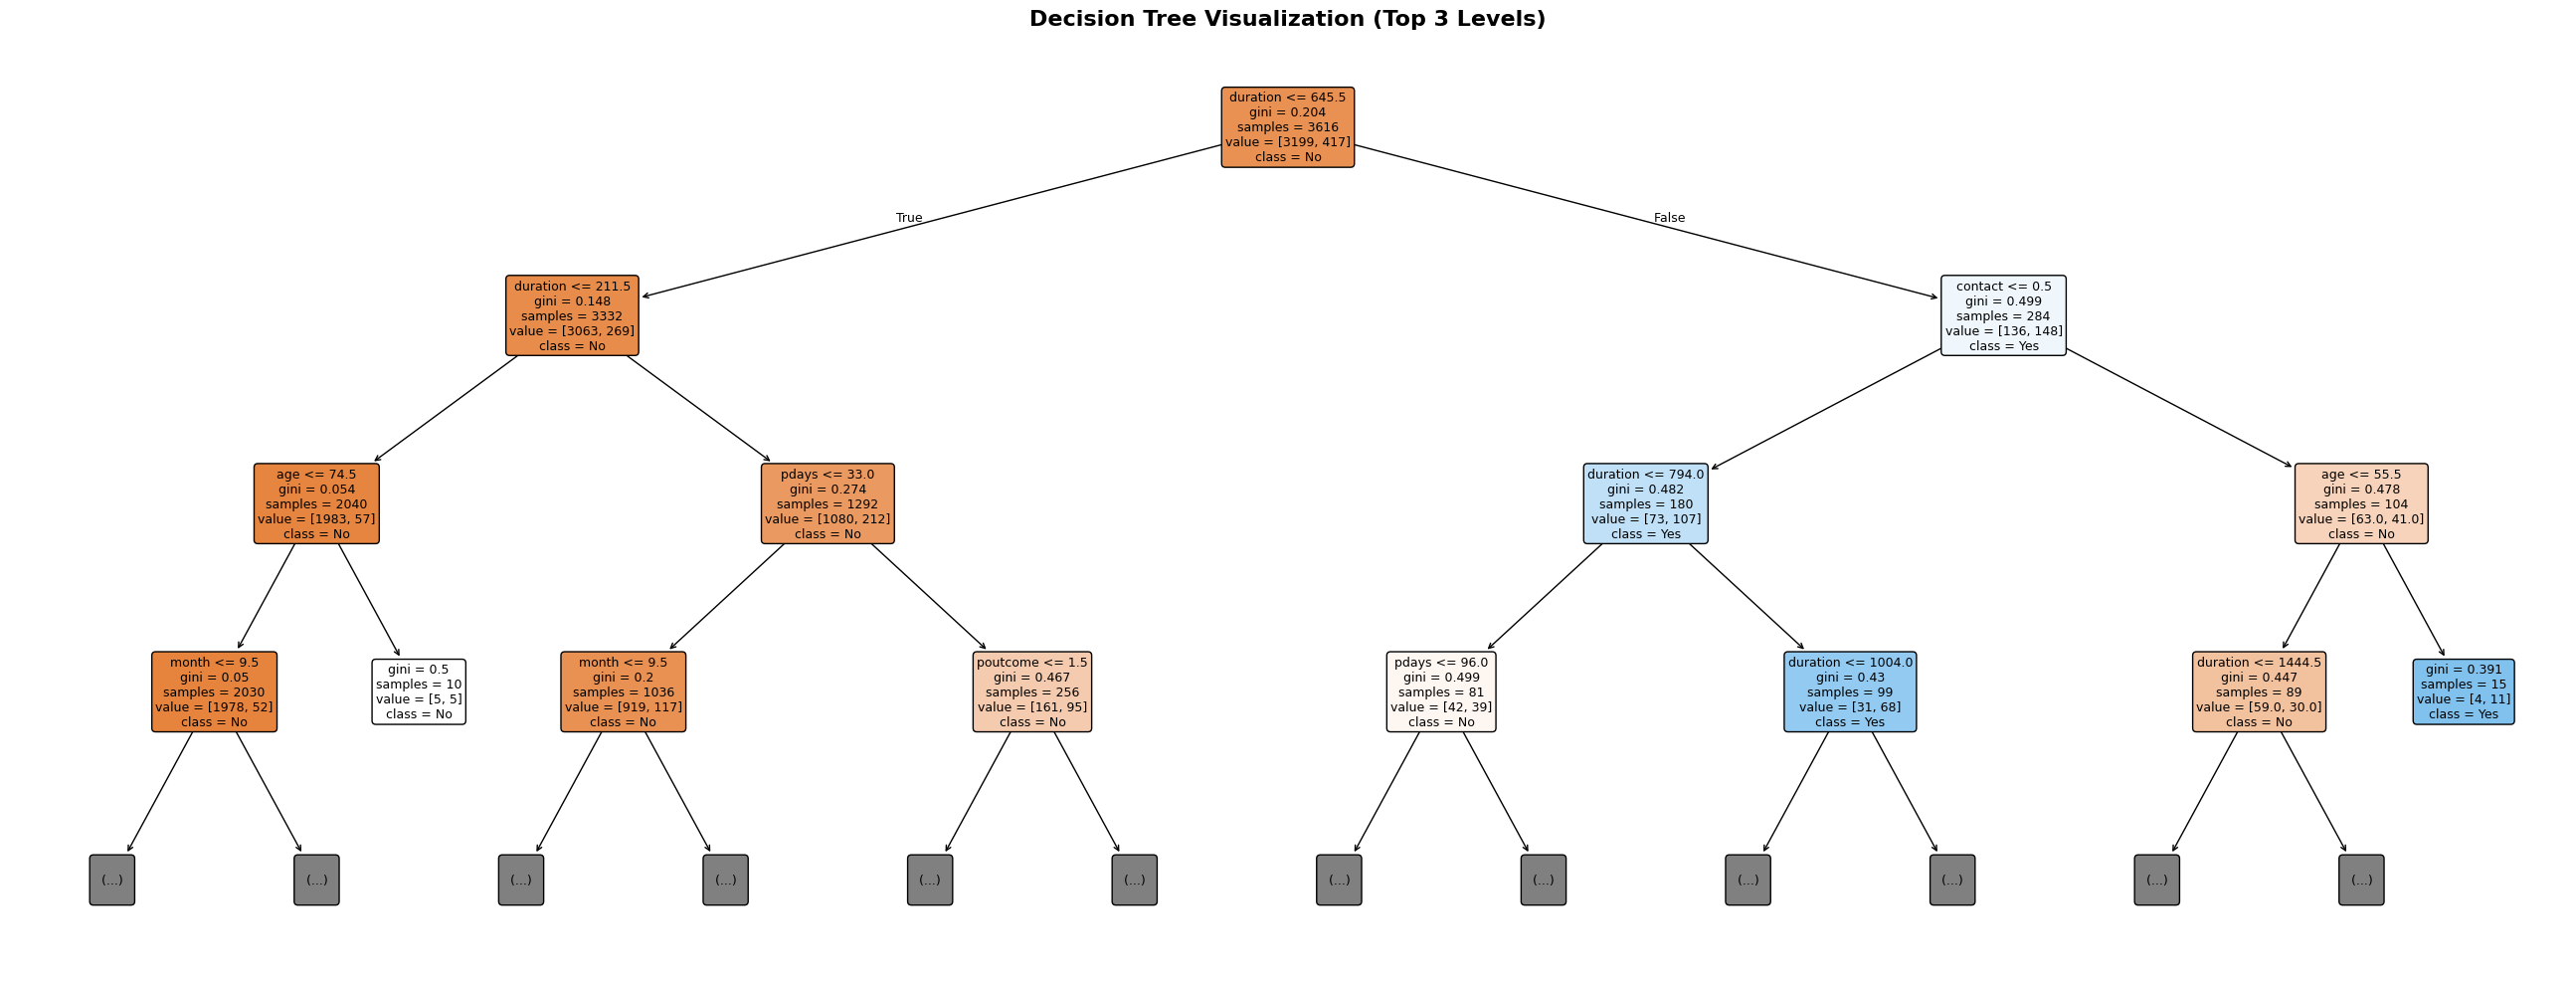

✅ Decision tree visualization saved!

📥 Downloading output files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


        PRODIGY INFOTECH — TASK 03 SUMMARY
  Dataset        : Bank Marketing (UCI)
  Total Samples  : 4521
  Total Features : 16
  Model          : Decision Tree Classifier
  Max Depth      : 5
  Accuracy       : 88.95%
  Top Feature    : duration
✅ TASK 03 COMPLETED SUCCESSFULLY!


In [3]:
# ============================================================
# PRODIGY INFOTECH - DATA SCIENCE INTERNSHIP
# Task 03: Decision Tree Classifier - Bank Marketing Dataset
# Author: Krisnapriyaa
# ============================================================

# --- 1. Install & Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

# --- 2. Load Dataset (Upload manually) ---
print("\n📂 Please upload your bank.csv file...")
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded['bank.csv']), sep=';')

print(f"\n📦 Dataset Shape: {df.shape}")
print(df.head())
print(df.dtypes)
print(f"\n🎯 Target Distribution:\n{df['y'].value_counts()}")

# --- 3. EDA ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bank Marketing Dataset - EDA', fontsize=16, fontweight='bold')

# Target distribution
df['y'].value_counts().plot(kind='bar', ax=axes[0],
                             color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed to Term Deposit?')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Age distribution
df[df['y'] == 'no']['age'].plot(kind='kde', ax=axes[1], label='No', color='#3498db')
df[df['y'] == 'yes']['age'].plot(kind='kde', ax=axes[1], label='Yes', color='#e74c3c')
axes[1].set_title('Age Distribution by Target', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('task03_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved!")

# --- 4. EDA Plot 2: Job & Subscription ---
plt.figure(figsize=(14, 5))
job_sub = df.groupby(['job', 'y']).size().unstack()
job_sub.plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='black', figsize=(14, 5))
plt.title('Subscription Count by Job Type', fontsize=14, fontweight='bold')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.savefig('task03_eda2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot 2 saved!")

# --- 5. Preprocessing ---
df_encoded = df.copy()
le = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print(f"\n🔄 Encoding {len(categorical_cols)} categorical columns: {categorical_cols}")

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("✅ Label encoding done!")

# --- 6. Feature & Target Split ---
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print(f"\n📊 Features: {X.shape[1]} | Samples: {X.shape[0]}")
print(f"Feature columns: {list(X.columns)}")

# --- 7. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n🔀 Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# --- 8. Train Decision Tree ---
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    criterion='gini',
    random_state=42
)
dt_model.fit(X_train, y_train)
print("\n✅ Decision Tree model trained!")
print(f"   Tree depth: {dt_model.get_depth()}")
print(f"   Number of leaves: {dt_model.get_n_leaves()}")

# --- 9. Predictions & Evaluation ---
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Model Accuracy: {accuracy * 100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

# --- 10. Confusion Matrix ---
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Decision Tree Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

# --- 11. Feature Importance ---
feature_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(feature_importances))]
bars = plt.barh(feature_importances.index[::-1],
                feature_importances.values[::-1], color=colors[::-1], edgecolor='black')
plt.title('Feature Importances - Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('task03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔑 Top 5 Most Important Features:")
for i, (feat, score) in enumerate(feature_importances.head().items(), 1):
    print(f"   {i}. {feat}: {score:.4f}")

print("✅ Feature importance plot saved!")

# --- 12. Decision Tree Visualization ---
plt.figure(figsize=(26, 10))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=['No', 'Yes'],
    filled=True,
    fontsize=9,
    rounded=True,
    max_depth=3
)
plt.title('Decision Tree Visualization (Top 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task03_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Decision tree visualization saved!")

# --- 13. Download all output images ---
print("\n📥 Downloading output files...")
files.download('task03_eda.png')
files.download('task03_eda2.png')
files.download('task03_confusion_matrix.png')
files.download('task03_feature_importance.png')
files.download('task03_decision_tree.png')

# --- 14. Final Summary ---
print("\n" + "="*55)
print("        PRODIGY INFOTECH — TASK 03 SUMMARY")
print("="*55)
print(f"  Dataset        : Bank Marketing (UCI)")
print(f"  Total Samples  : {df.shape[0]}")
print(f"  Total Features : {X.shape[1]}")
print(f"  Model          : Decision Tree Classifier")
print(f"  Max Depth      : 5")
print(f"  Accuracy       : {accuracy * 100:.2f}%")
print(f"  Top Feature    : {feature_importances.index[0]}")
print("="*55)
print("✅ TASK 03 COMPLETED SUCCESSFULLY!")